# Data

In [4]:
from huggingface_hub import hf_hub_download, login

In [5]:
login()

In [10]:
hf_hub_download(repo_id='Jungle15/GDP-HMM_Challenge', filename='train_HaN.zip', repo_type="dataset", local_dir='.')

train_HaN.zip:   0%|          | 0.00/17.6G [00:00<?, ?B/s]

'train_HaN.zip'

In [11]:
hf_hub_download(repo_id='Jungle15/GDP-HMM_Challenge', filename='train_Lung.zip', repo_type="dataset", local_dir='.')

train_Lung.zip:   0%|          | 0.00/21.4G [00:00<?, ?B/s]

'train_Lung.zip'

# Train

In [1]:
from pathlib import Path
import sys

code_dir = Path('/workspace/gdp-hmm-model')
sys.path.append(str(code_dir)) # Need to be string
sys.path.append(str(code_dir/'mednext'))

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from nnunet_mednext import create_mednext_v1
import yaml
from pprint import pprint

from tqdm import tqdm
import numpy as np

In [3]:
%load_ext autoreload
%autoreload 2

import data_loader



In [4]:
cfig = yaml.load(open(code_dir / 'config_files/config.yaml'), Loader=yaml.FullLoader)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
# loaders = data_loader.GetLoader(cfig = cfig['loader_params'])
# train_loader =loaders.train_dataloader()
# val_loader = loaders.val_dataloader()

In [6]:
model = create_mednext_v1( num_input_channels = cfig['model_params']['num_input_channels'],
  num_classes = cfig['model_params']['out_channels'],
  model_id = cfig['model_params']['model_id'],          # S, B, M and L are valid model ids
  kernel_size = cfig['model_params']['kernel_size'],   # 3x3x3 and 5x5x5 were tested in publication
  deep_supervision = cfig['model_params']['deep_supervision']
).to(device)

In [6]:
model = create_mednext_v1( num_input_channels = 7,
  num_classes = cfig['model_params']['out_channels'],
  model_id = cfig['model_params']['model_id'],          # S, B, M and L are valid model ids
  kernel_size = cfig['model_params']['kernel_size'],   # 3x3x3 and 5x5x5 were tested in publication
  deep_supervision = cfig['model_params']['deep_supervision']
).to(device)

In [8]:
model.load_state_dict(torch.load('weights/7c_temp.pt'))

<All keys matched successfully>

# Dataset and DataLoader

In [9]:
from pathlib import Path
import numpy as np
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

In [10]:
# Fixed length, random sampled
# extra param: size -> size of the dataset

class ChallengeData(Dataset):
    def __init__(self, data_dir, ids, size=None):
        super().__init__()
        self.data_dir = Path(data_dir)
        self.ids = ids
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

        self.size = size if size is not None else len(ids)
        self._sample()

    def __len__(self):
        return self.size

    def _sample(self):
        if self.size < len(self.ids):
            self.current_ids = np.random.choice(self.ids, self.size, replace=False).tolist()
            print('Dataset resampled')
        else:
            self.current_ids = self.ids.copy()
            print('Dataset all samples used')

    def __getitem__(self, idx):
        npz_path = self.data_dir / f'{self.current_ids[idx]}.npz'

        data_dict = dict(np.load(npz_path))

        # Unsqueeze the 1st dim: x -> (8, 96, 128, 144)
        x = torch.from_numpy(data_dict['data'])[0].to(self.device)
        y = torch.from_numpy(data_dict['label'])[0].to(self.device)

        # Mask, derived from x
        body_mask = x[3:4,...].bool()
        outbody_mask = ~body_mask
        ptv_mask = x[1:2, ...].bool()
        near_mask = torch.logical_and(~ptv_mask, body_mask)

        if idx==self.size-1: self._sample()

        info = x[-1].mean((1, 2))[:4].cpu().tolist()
            
        return x[:-1], y, body_mask, outbody_mask, ptv_mask, near_mask, info

In [11]:
from sklearn.model_selection import train_test_split

others, test_ids = train_test_split(range(2728), test_size=0.3, random_state=1234)
train_ids, val_ids = train_test_split(others, test_size=0.3, random_state=1234)

In [12]:
batch_size = 4

data_tr = ChallengeData('/workspace/data/train_data_dict', train_ids, size=100)
loader_tr = DataLoader(data_tr, batch_size=batch_size, shuffle=False)

data_vl = ChallengeData('/workspace/data/train_data_dict', val_ids, size=20)
loader_vl = DataLoader(data_vl, batch_size=batch_size, shuffle=False)

data_ts = ChallengeData('/workspace/data/train_data_dict', test_ids)
loader_ts = DataLoader(data_ts, batch_size=batch_size, shuffle=False)


Dataset resampled
Dataset resampled
Dataset all samples used


In [13]:
len(data_tr), len(data_vl), len(data_ts)

(100, 20, 819)

In [14]:
x, y, body_mask, outbody_mask, ptv_mask, near_mask, info = data_tr[0]

In [15]:
x.shape, info

(torch.Size([7, 96, 128, 144]), [1.0, 3.0, 2.0, 2.0])

In [16]:
optimizer = optim.Adam(model.parameters(), lr=cfig['lr'])
criterion = nn.L1Loss()
epochs = 10

In [17]:
def cal_error(pred, gt, body):
    isodose_5Gy_mask = ((gt > 0.5) | (pred > 0.5)) & (body > 0)
    isodose_ref_5Gy_mask = (gt > 0.5) & (body > 0)
    diff = gt - pred
    error = torch.sum(torch.abs(diff)[isodose_5Gy_mask > 0]) / torch.sum(isodose_ref_5Gy_mask)
    return error

def custom_loss(outputs, y, body_mask, outbody_mask, ptv_mask, near_mask, _id):
    if _id == 1:
        loss = criterion(outputs, y)
    if _id == 2:
        loss = criterion(outputs[body_mask], y[body_mask])
    if _id == 3:
        loss = criterion(outputs[body_mask], y[body_mask]) + 5 * criterion(outputs[near_mask], y[near_mask])
    if _id == 4:
        loss = cal_error(outputs, y, body_mask) + criterion(outputs, y) + torch.max(outputs[outbody_mask])

    return loss

def iso_5_dice(pred, gt, body):
    iso_mask = ((gt > 0.5) | (pred > 0.5)) & (body > 0)
    iso_mask_gt = (gt > 0.5) & (body > 0)
    return 2*(iso_mask*iso_mask_gt).sum() / (iso_mask.sum() + iso_mask_gt.sum())
    

In [18]:
loss_id = 3

In [57]:
5e-4

0.0005

In [28]:
optimizer = optim.Adam(model.parameters(), lr=1e-6)

In [29]:
model.train()

for epoch in range(epochs):
    
    pbar = tqdm(loader_tr, f'Epoch {epoch}')
    
    train_loss = []
    for x, y, body_mask, outbody_mask, ptv_mask, near_mask, info in pbar:
        
      # Forward pass
      outputs = model(x.to(device))

      if loss_id == 1:
        loss = criterion(outputs, y)
      if loss_id == 2:
        loss = criterion(outputs[body_mask], y[body_mask])
      if loss_id == 3:
        loss = 1 * criterion(outputs[body_mask], y[body_mask]) + \
               10 * criterion(outputs[near_mask], y[near_mask]) + \
               cal_error(outputs, y, body_mask) 
               # 10 * iso_5_dice(outputs, y, body_mask) 
              # 10 * criterion(outputs[outbody_mask], y[outbody_mask])
               
    
      if loss_id == 4:
        loss = cal_error(outputs, y, body_mask) + criterion(outputs, y) + torch.max(outputs[outbody_mask])
    
      # Backward pass and optimization
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
    
      train_loss.append(loss.detach().cpu().item())
      pbar.set_postfix_str(f'Loss: {loss.item():.3f}')
    
    val_loss = []
    model.eval()
    for x, y, body_mask, outbody_mask, ptv_mask, near_mask, info in loader_vl:
        with torch.no_grad():
            outputs = model(x.to(device))
            loss = cal_error(outputs, y, body_mask)
            val_loss.append(loss.detach().cpu().item())
    
    print(f'Train loss: {np.mean(train_loss):.3f} ({np.std(train_loss):.3f}) '+ \
          f'Val loss: {np.mean(val_loss):.3f} ({np.std(val_loss):.3f})')


Epoch 0:  96%|█████████▌| 24/25 [00:23<00:00,  1.00it/s, Loss: 2.011]

Dataset resampled


Epoch 0: 100%|██████████| 25/25 [00:24<00:00,  1.01it/s, Loss: 2.636]


Dataset resampled
Train loss: 2.400 (0.417) Val loss: 0.370 (0.044)


Epoch 1:  96%|█████████▌| 24/25 [00:23<00:00,  1.00it/s, Loss: 3.660]

...

Dataset resampled
Train loss: 2.446 (0.543) Val loss: 0.334 (0.031)


Epoch 9:  96%|█████████▌| 24/25 [00:23<00:00,  1.00it/s, Loss: 2.023]

Dataset resampled


Epoch 9: 100%|██████████| 25/25 [00:24<00:00,  1.00it/s, Loss: 2.542]


Dataset resampled
Train loss: 2.241 (0.448) Val loss: 0.348 (0.038)


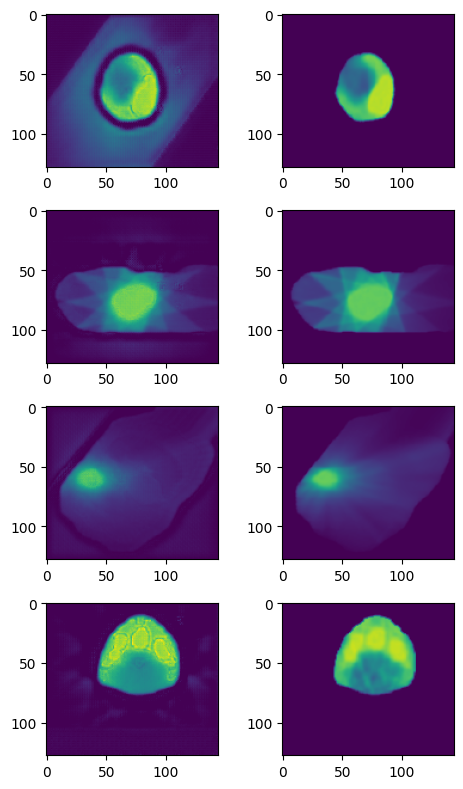

In [30]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(4, 2, figsize=(5, 8))
for i in range(4):
    ax[i,0].imshow(outputs[i,0,50].detach().cpu(), vmin=0, vmax=8)
    ax[i,1].imshow(y.cpu()[i,0,50], vmin=0, vmax=8)
plt.tight_layout()

In [28]:
ref_dose = y.cpu().numpy()
prediction = outputs.detach().cpu().numpy()
body = body_mask.cpu().numpy()

isodose_5Gy_mask = ((ref_dose > 5) | (prediction > 5)) & (body > 0) # the mask include the body AND the region where the dose/prediction is higher than 5Gy

isodose_ref_5Gy_mask = (ref_dose > 5) & (body > 0) # the mask include the body AND the region where the ref is higher than 5Gy

diff = ref_dose - prediction

error = np.sum(np.abs(diff)[isodose_5Gy_mask > 0]) / np.sum(isodose_ref_5Gy_mask)

In [29]:
error

1.2371281583092275

In [60]:
cal_error(outputs.detach().cpu(), y.cpu(), body_mask.cpu().numpy())

tensor(0.6650)

In [39]:
error

1.3662197851783693

# Test

In [31]:
ts_loss = []
model.eval()

pbar = tqdm(loader_ts)
for x, y, body_mask, outbody_mask, ptv_mask, near_mask, info in pbar:
    with torch.no_grad():
        outputs = model(x.to(device))
        # loss = criterion(outputs, y)
        
        loss = cal_error(outputs, y, body_mask)
        ts_loss.append(loss.detach().cpu().item())
        pbar.set_postfix_str(f'Test loss: {np.mean(ts_loss):.3f}')



100%|██████████| 205/205 [01:52<00:00,  1.83it/s, Test loss: 0.348]

Dataset all samples used


In [32]:
## 7c v1 - 
# torch.save(model.state_dict(), 'weights/7c_v1.pt') # Test loss: 0.385
# torch.save(model.state_dict(), 'weights/7c_v2.pt') # Test loss: 0.348

### Candidate 1
* Has the lowest loss so far, but the image can be improved.

In [62]:
torch.save(model.state_dict(), 'weights/candidate_1.pt')

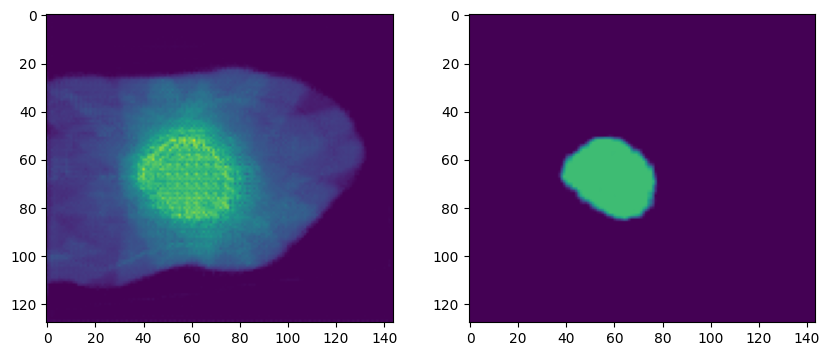

In [65]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(outputs[0,0,50].detach().cpu(), vmin=0, vmax=8)
ax[1].imshow(x.cpu()[0,0,50], vmin=0, vmax=8)

In [71]:
model.load_state_dict(torch.load('weights/candidate_1.pt'))

<All keys matched successfully>

## Candidate 2
Test loss: 0.489

In [114]:
torch.save(model.state_dict(), 'weights/candidate_2.pt')

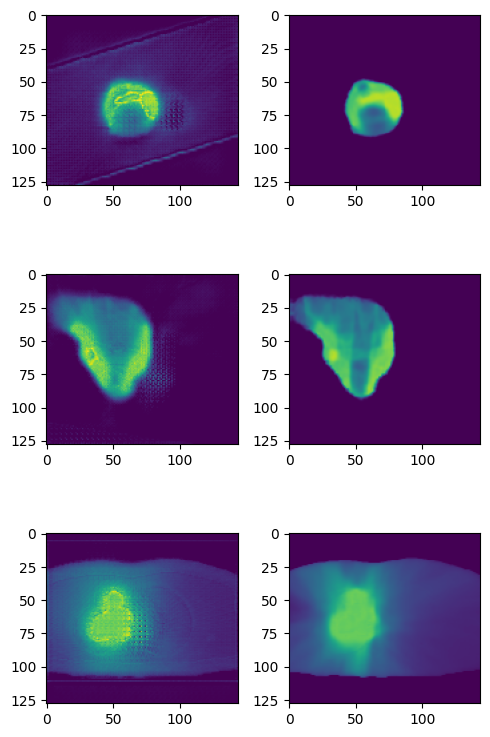

In [166]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(3, 2, figsize=(5, 8))
for i in range(3):
    ax[i,0].imshow(outputs[i,0,50].detach().cpu(), vmin=0, vmax=8)
    ax[i,1].imshow(y.cpu()[i,0,50], vmin=0, vmax=8)
plt.tight_layout()

# C2 + fine tuning
Fix all but the last two layers. Test loss: 0.485

v2: reduced learning rate to 1e-5. Test loss: 0.430
v3.1, 3.2: further reduced lr to 1e-6. Test loss: 0.424, 0.425. Mosaiq is still there but more natural.

In [107]:
model.load_state_dict(torch.load('weights/candidate_2_ft_v2.pt'))

<All keys matched successfully>

In [108]:
model.eval()
model.out_0.train()
model.dec_block_0.train()

model.up_0.train()


MedNeXtUpBlock(
  (conv1): ConvTranspose3d(64, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), groups=64)
  (norm): GroupNorm(64, 64, eps=1e-05, affine=True)
  (conv2): Conv3d(64, 128, kernel_size=(1, 1, 1), stride=(1, 1, 1))
  (act): GELU(approximate='none')
  (conv3): Conv3d(128, 32, kernel_size=(1, 1, 1), stride=(1, 1, 1))
  (res_conv): ConvTranspose3d(64, 32, kernel_size=(1, 1, 1), stride=(2, 2, 2))
)

In [109]:
model.stem.training, model.out_0.training, model.dec_block_0.training, model.up_0.training

(False, True, True, True)

In [72]:
def img_grad(img):
    return img[..., :-1, :-1, :-1] - img[..., 1:, 1:, 1:]

def cal_grad_loss(pred, y, mask):
    _mask = mask[..., :-1, :-1, :-1]
    return criterion(img_grad(pred)[_mask], img_grad(y)[_mask])

In [115]:
optimizer = optim.Adam(model.parameters(), lr=1e-6)
loss_id = 5

In [134]:
for epoch in range(1):
    
    pbar = tqdm(loader_tr, f'Epoch {epoch}')
    
    train_loss = []
    for x, y, body_mask, outbody_mask, ptv_mask, near_mask in pbar:
        
      # Forward pass
      outputs = model(x.to(device))

      if loss_id == 1:
        loss = criterion(outputs, y)
      if loss_id == 2:
        loss = criterion(outputs[body_mask], y[body_mask])
      if loss_id == 3:
        loss = 1 * criterion(outputs[body_mask], y[body_mask]) + \
               10 * criterion(outputs[near_mask], y[near_mask]) + \
               cal_error(outputs, y, body_mask) 
               # 30*iso_5_dice(outputs, y, body_mask) + \
              # 10 * criterion(outputs[outbody_mask], y[outbody_mask])
               
    
      if loss_id == 4:
        loss = cal_error(outputs, y, body_mask) + criterion(outputs, y) + torch.max(outputs[outbody_mask])

      if loss_id == 5:
        loss = 1 * cal_error(outputs, y, body_mask)  + \
               50 * cal_grad_loss(outputs, y, body_mask)
    
      # Backward pass and optimization
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
    
      train_loss.append(loss.detach().cpu().item())
      pbar.set_postfix_str(f'Loss: {loss.item():.3f}')
    
    val_loss = []
    model.eval()
    for x, y, body_mask, outbody_mask, ptv_mask, near_mask in loader_vl:
        with torch.no_grad():
            outputs = model(x.to(device))
            loss = cal_error(outputs, y, body_mask)
            val_loss.append(loss.detach().cpu().item())
    
    print(f'Train loss: {np.mean(train_loss):.3f} ({np.std(train_loss):.3f}) '+ \
          f'Val loss: {np.mean(val_loss):.3f} ({np.std(val_loss):.3f})')


Epoch 0:  96%|█████████▌| 24/25 [00:23<00:00,  1.03it/s, Loss: 8.442] 

Dataset resampled


Epoch 0: 100%|██████████| 25/25 [00:24<00:00,  1.03it/s, Loss: 8.442]


Dataset resampled
Train loss: 7.180 (1.659) Val loss: 0.401 (0.047)


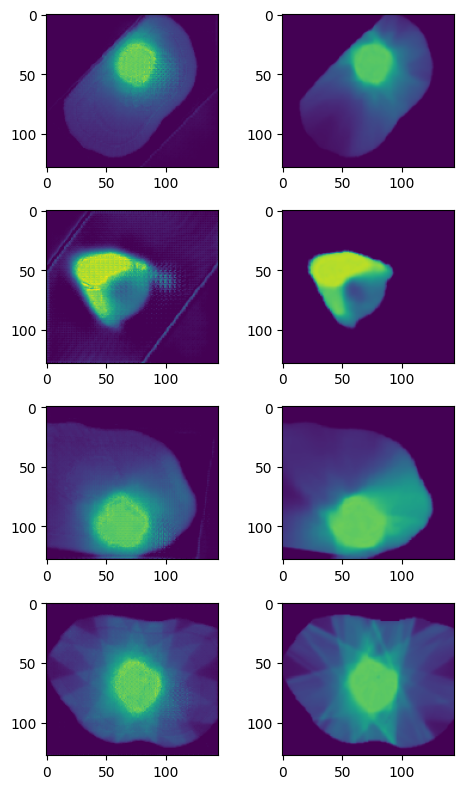

In [135]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(4, 2, figsize=(5, 8))
for i in range(4):
    ax[i,0].imshow(outputs[i,0,50].detach().cpu(), vmin=0, vmax=8)
    ax[i,1].imshow(y.cpu()[i,0,50], vmin=0, vmax=8)
plt.tight_layout()

In [126]:
ts_loss = []
model.eval()

pbar = tqdm(loader_ts)
for x, y, body_mask, outbody_mask, ptv_mask, near_mask in pbar:
    with torch.no_grad():
        outputs = model(x.to(device))
        # loss = criterion(outputs, y)
        
        loss = cal_error(outputs, y, body_mask)
        ts_loss.append(loss.detach().cpu().item())
        pbar.set_postfix_str(f'Test loss: {np.mean(ts_loss):.3f}')



100%|██████████| 205/205 [01:47<00:00,  1.90it/s, Test loss: 0.425]

Dataset all samples used


In [127]:
# temp = model.state_dict() # Test loss: 0.424
# temp2 = model.state_dict() # Test loss: 0.425

In [119]:
model.load_state_dict(temp)

<All keys matched successfully>

In [136]:
torch.save(temp, 'weights/candidate_2_ft_v3.1.pt')
torch.save(temp2, 'weights/candidate_2_ft_v3.2.pt')

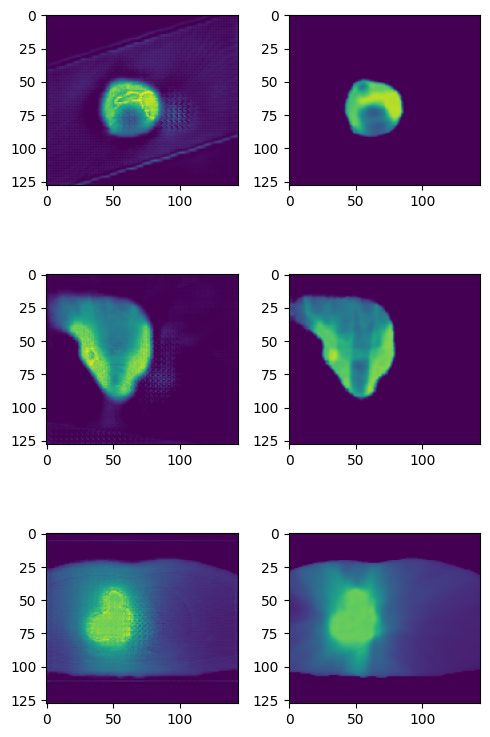

In [41]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(3, 2, figsize=(5, 8))
for i in range(3):
    ax[i,0].imshow(outputs[i,0,50].detach().cpu(), vmin=0, vmax=8)
    ax[i,1].imshow(y.cpu()[i,0,50], vmin=0, vmax=8)
plt.tight_layout()

# Misc.

In [29]:
model2 = create_mednext_v1( num_input_channels = cfig['model_params']['num_input_channels'],
  num_classes = cfig['model_params']['out_channels'],
  model_id = cfig['model_params']['model_id'],          # S, B, M and L are valid model ids
  kernel_size = cfig['model_params']['kernel_size'],   # 3x3x3 and 5x5x5 were tested in publication
  deep_supervision = cfig['model_params']['deep_supervision']
).to(device)

In [30]:
model2.load_state_dict(torch.load('weights/epoch_20_loss_1.pt'))

<All keys matched successfully>

In [31]:
outputs = model2(x)

# Inspecting the beam plates

In [118]:
len(data_ts)

819

In [168]:
x, y, body_mask, outbody_mask, ptv_mask, near_mask = data_ts[-3]

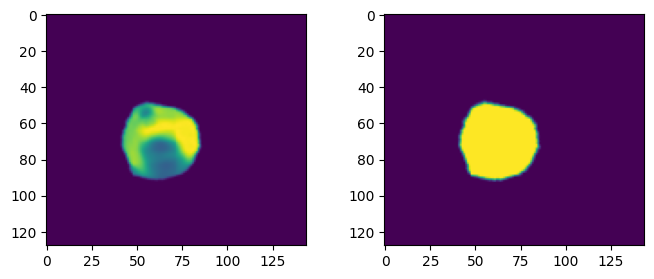

In [171]:
fig, ax = plt.subplots(1, 2, figsize=(8,3))
ax[0].imshow(y.cpu()[0, 50])
ax[1].imshow(x.cpu()[3, 50])

In [122]:
data_ts.ids[-3]

1900

In [125]:
d = np.load('/workspace/data/train_data_dict/1900.npz')

In [126]:
d

In [127]:
d.keys()

KeysView(<numpy.lib.npyio.NpzFile object at 0x7babce7c8dc0>)

In [128]:
dict(d).keys()

dict_keys(['index', 'id', 'data', 'label'])

In [129]:
d['id']

array(['HN-HMR-026+S2A4Ac+MOS_4398'], dtype='<U26')

In [132]:
!cat meta_files/meta_data.csv | grep HN-HMR-026+S2A4Ac+MOS_4398

HN-HMR-026,S2A4Ac,True,2,1,train,train,/pct_ids/users/z004b27b/data/GDP-HMM_Challenge/HaN/train/HN-HMR-026+S2A4Ac+MOS_4398.npz,1.028,1.044,3,70.0


In [133]:
import pandas as pd

In [134]:
df = pd.read_csv('meta_files/meta_data.csv')

In [135]:
df.columns

Index(['PID', 'PlanID', 'isVMAT', 'cohort', 'site', 'phase', 'dev_split',
       'npz_path', 'D05_div_D95', 'max_div_D95', 'num_PTV', 'HighDose'],
      dtype='object')

In [144]:
df[df['npz_path']=='/pct_ids/users/z004b27b/data/GDP-HMM_Challenge/HaN/train/HN-HMR-026+S2A4Ac+MOS_4398.npz']

,PID,PlanID,isVMAT,cohort,site,phase,dev_split,npz_path,D05_div_D95,max_div_D95,num_PTV,HighDose
553,HN-HMR-026,S2A4Ac,True,2,1,train,train,/pct_ids/users/z004b27b/data/GDP-HMM_Challenge...,1.028,1.044,3,70.0


In [ ]:
x_ = x.clone()
x_[:, 3, ...] = 0
with torch.no_grad():
    y_hat = model(x_)
fig, ax = plt.subplots(4, 2, figsize=(5, 8))
for i in range(4):
    ax[i,0].imshow(y_hat[i,0,50].detach().cpu(), vmin=0, vmax=8)
    ax[i,1].imshow(y.cpu()[i,0,50], vmin=0, vmax=8)
plt.tight_layout()